# Lane 2: Routing

Owner: Ali Abdul-Hameed. Development notebook; finished cells are copied into `notebook.ipynb` section 2 at assembly. See `docs/` and `setup.md`.

In [1]:
import sys
sys.path.insert(0, "..")  # this notebook lives in dev/; make src/ importable

from src import llm, tools
from src.llm import chat, handoff


An LLM router labels each item as `earnings`, `news`, or `market`, then hands the item to a specialist with a narrower prompt and the right supporting data.

**Contract:** `route(item) -> "earnings" | "news" | "market"`; `analyze_earnings / analyze_news / analyze_market(symbol, context) -> str`; `route_and_analyze(symbol, items) -> [{"item", "route", "analysis"}]`.

The router deliberately reads only the item's `title` and `summary`, so it works with either a raw Yahoo Finance news item or an article that already passed through Lane 1. Earnings analysis adds cached fundamentals, market analysis adds cached price summaries, and news analysis uses the routed article plus the chain summary when one is available.

`route_and_analyze()` accepts either a list of articles or the full dictionary returned by `run_chain()`. Every dispatch is printed with `handoff()` so the notebook visibly demonstrates multi-agent routing for the grader.


In [2]:
import json

VALID_ROUTES = {"earnings", "news", "market"}

ROUTER_SYSTEM = """You are the Router in a financial research system.
Choose exactly one specialist for the supplied item:

- earnings: reported quarterly or annual results, revenue, EPS, margins,
  earnings growth, financial guidance, or an earnings call.
- market: stock-price performance, valuation, trading activity, analyst
  price targets, sector moves, or broader market/macro effects on the stock.
- news: company events that are not primarily earnings or market-price
  analysis, such as products, leadership, regulation, litigation,
  partnerships, operations, or corporate announcements.

Classify the dominant subject, even when an item touches more than one area.
Return JSON only in exactly this shape:
{"route": "earnings"}
The value must be one of: earnings, news, market.
"""


def _context_text(context, max_chars=6000):
    """Convert specialist context to compact prompt text."""
    if isinstance(context, str):
        text = context
    else:
        text = json.dumps(context, ensure_ascii=False, default=str, indent=2)
    return text[:max_chars]


def route(item):
    """Return the specialist label for one raw or chain-processed news item."""
    if not isinstance(item, dict):
        raise TypeError("route(item) expects a dictionary")

    title = (item.get("title") or "").strip()
    summary = (item.get("summary") or "").strip()
    if not title and not summary:
        raise ValueError("route(item) needs a title, summary, or both")

    user = f"Title: {title or '(none)'}\nSummary: {summary or '(none)'}"
    result = chat(
        system=ROUTER_SYSTEM,
        user=user,
        json_mode=True,
        max_tokens=100,
        temperature=1.0,
        agent="Router",
    )

    label = str(result.get("route", "")).strip().lower()
    if label not in VALID_ROUTES:
        raise ValueError(
            f"Router returned {label!r}; expected one of {sorted(VALID_ROUTES)}"
        )
    return label


def analyze_earnings(symbol, context):
    """Analyze routed earnings content using cached company fundamentals."""
    fundamentals = tools.get_fundamentals(symbol)
    system = """You are the Earnings Specialist in a financial research system.
Analyze the routed content using only the supplied context and fundamentals.
Focus on reported financial performance, growth, margins, earnings, or guidance
when relevant. Clearly separate article claims from the Yahoo Finance data.
Write 2-4 concise sentences. Do not predict the stock price and do not give
buy, sell, or hold advice.
"""
    user = (
        f"Symbol: {symbol}\n\n"
        f"Routed context:\n{_context_text(context)}\n\n"
        "Cached Yahoo Finance fundamentals:\n"
        f"{json.dumps(fundamentals, indent=2, default=str)}"
    )
    return chat(
        system=system,
        user=user,
        max_tokens=350,
        temperature=1.0,
        agent="Earnings Specialist",
    )


def analyze_news(symbol, context):
    """Analyze routed company news; chain summary is used when supplied."""
    system = """You are the News Specialist in a financial research system.
Analyze the supplied company-news context. Explain what happened and why it
could matter to the company, while staying grounded only in the supplied text.
If both an individual item and a chain summary are present, use the chain
summary as broader context without inventing facts. Write 2-4 concise
sentences. Do not predict the stock price and do not give investment advice.
"""
    user = f"Symbol: {symbol}\n\nNews context:\n{_context_text(context)}"
    return chat(
        system=system,
        user=user,
        max_tokens=350,
        temperature=1.0,
        agent="News Specialist",
    )


def analyze_market(symbol, context):
    """Analyze routed market content using cached price-summary data."""
    prices = tools.get_prices(symbol)
    market_data = {
        key: value
        for key, value in prices.items()
        if key not in {"dates", "close"}
    }
    system = """You are the Market Specialist in a financial research system.
Analyze the routed content using only the supplied context and cached market
data. Focus on observable price performance, range, trading context, valuation
or broader market effects when relevant. Do not invent catalysts or forecasts.
Write 2-4 concise sentences and do not give buy, sell, or hold advice.
"""
    user = (
        f"Symbol: {symbol}\n\n"
        f"Routed context:\n{_context_text(context)}\n\n"
        "Cached Yahoo Finance market summary:\n"
        f"{json.dumps(market_data, indent=2, default=str)}"
    )
    return chat(
        system=system,
        user=user,
        max_tokens=350,
        temperature=1.0,
        agent="Market Specialist",
    )


SPECIALISTS = {
    "earnings": analyze_earnings,
    "news": analyze_news,
    "market": analyze_market,
}

SPECIALIST_NAMES = {
    "earnings": "Earnings Specialist",
    "news": "News Specialist",
    "market": "Market Specialist",
}


def route_and_analyze(symbol, items):
    """Route each item, dispatch it, and return the routing decisions."""
    chain_summary = None

    # Accept run_chain(symbol) directly as a convenience for the agent lane.
    if isinstance(items, dict) and "articles" in items:
        chain_summary = items.get("summary")
        items = items.get("articles", [])
    elif isinstance(items, dict):
        items = [items]
    else:
        items = list(items)

    results = []
    for item in items:
        label = route(item)
        specialist_name = SPECIALIST_NAMES[label]
        handoff(
            "Router",
            specialist_name,
            item.get("title") or item.get("summary") or str(item),
        )

        specialist_context = item
        if label == "news" and chain_summary:
            specialist_context = {
                "item": item,
                "chain_summary": chain_summary,
            }

        analysis = SPECIALISTS[label](symbol, specialist_context)
        results.append(
            {
                "item": item,
                "route": label,
                "analysis": analysis,
            }
        )

    return results


## Demonstration

The demonstration builds a three-item mixed batch from the committed AAPL cache: one fundamentals/earnings item, one real Yahoo Finance company-news item, and one market-performance item. The router must choose a specialist for each item, and the specialist output is shown beside the decision.

The bar chart makes the routing behavior visible in the final PDF. Because all supporting Yahoo Finance data comes from the committed cache, rerunning the notebook does not change the evidence used by the specialists.


Router → Earnings Specialist: Apple earnings and fundamentals snapshot
Router → News Specialist: Apple’s Cook calls Australia’s social media curbs ‘world-lea
Router → Market Specialist: Apple six-month market performance


,item,route,analysis excerpt
0,Apple earnings and fundamentals snapshot,earnings,The routed article summary cites Apple’s reven...
1,Apple’s Cook calls Australia’s social media cu...,news,Tim Cook called Australia’s social media restr...
2,Apple six-month market performance,market,"Over the past six months, AAPL rose 35.25%, cl..."


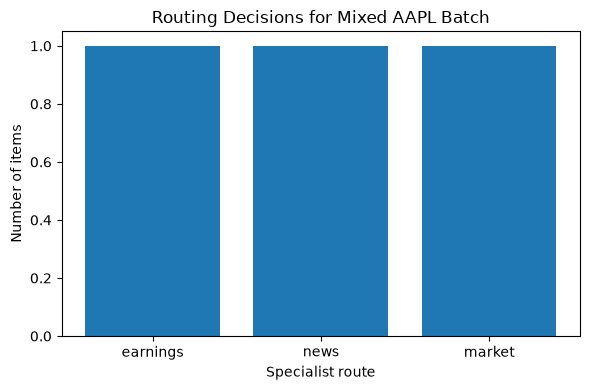

In [3]:
if __name__ == "__main__":
    import matplotlib.pyplot as plt
    import pandas as pd
    from IPython.display import display

    symbol = "AAPL"
    fundamentals = tools.get_fundamentals(symbol)
    prices = tools.get_prices(symbol)
    company_news = tools.get_news(symbol)[0]

    demo_items = [
        {
            "title": "Apple earnings and fundamentals snapshot",
            "summary": (
                f"Revenue is {fundamentals.get('revenue_b')} billion "
                f"{fundamentals.get('currency')}; profit margin is "
                f"{fundamentals.get('profit_margin_pct')}% and earnings "
                f"growth is {fundamentals.get('earnings_growth_pct')}%."
            ),
        },
        company_news,
        {
            "title": "Apple six-month market performance",
            "summary": (
                f"Over {prices.get('period')}, AAPL changed "
                f"{prices.get('change_pct')}%. The latest close was "
                f"{prices.get('last_close')}, with a high of "
                f"{prices.get('high')} and low of {prices.get('low')}."
            ),
        },
    ]

    routed = route_and_analyze(symbol, demo_items)
    routing_table = pd.DataFrame(
        {
            "item": [row["item"].get("title", "") for row in routed],
            "route": [row["route"] for row in routed],
            "analysis excerpt": [row["analysis"][:180] for row in routed],
        }
    )
    display(routing_table)

    route_order = ["earnings", "news", "market"]
    route_counts = (
        routing_table["route"]
        .value_counts()
        .reindex(route_order, fill_value=0)
    )

    plt.figure(figsize=(6, 4))
    plt.bar(route_counts.index, route_counts.values)
    plt.title("Routing Decisions for Mixed AAPL Batch")
    plt.xlabel("Specialist route")
    plt.ylabel("Number of items")
    plt.tight_layout()
    plt.show()
